## comparing point source .dat input files

In [1]:
from pathlib import Path
from typing import List, Dict

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# Loading utilities
# ============================================================

def load_rcyr_file(path: str | Path, skip_title_lines: int = 5) -> pd.DataFrame:
    """
    Load a SWAT 'rcyr'-style yearly file.

    Assumptions
    ----------
    - Lines 1–5 : title / comment lines
    - Line 6    : header row with column names (space-separated)
    - Line 7+   : data rows (space-separated)
    - First column is YEAR (x-axis for plotting)

    Parameters
    ----------
    path : str or Path
        Path to the file.
    skip_title_lines : int, default 5
        Number of non-header lines at the top of the file.

    Returns
    -------
    df : pandas.DataFrame
        DataFrame with:
        - 'YEAR' column as int
        - remaining columns as float (if parsable)
    """
    path = Path(path)

    df = pd.read_csv(
        path,
        delim_whitespace=True,      # columns are space-separated
        skiprows=skip_title_lines,  # skip title lines, next line is header
        header=0,
    )

    # Ensure first column is called YEAR (case-insensitive)
    first_col = df.columns[0]
    if first_col.upper() != "YEAR":
        df = df.rename(columns={first_col: "YEAR"})

    # Make sure YEAR is integer
    df["YEAR"] = df["YEAR"].astype(int)

    return df


def load_rcyr_files(paths: List[str | Path], skip_title_lines: int = 5) -> Dict[Path, pd.DataFrame]:
    """
    Load multiple rcyr-style files into a dict of DataFrames.

    Parameters
    ----------
    paths : list of str or Path
        Paths to the files.
    skip_title_lines : int, default 5
        Number of title lines to skip before header.

    Returns
    -------
    dfs : dict[Path, DataFrame]
        Mapping: file_path -> DataFrame
    """
    dfs: Dict[Path, pd.DataFrame] = {}
    for p in paths:
        p = Path(p)
        print(f"Loading {p} ...")
        dfs[p] = load_rcyr_file(p, skip_title_lines=skip_title_lines)
    return dfs


# ============================================================
# Plotting utilities
# ============================================================

def get_common_data_columns(dfs: Dict[Path, pd.DataFrame]) -> list[str]:
    """
    Get the list of columns that are present in ALL DataFrames,
    excluding the YEAR column.
    """
    common_cols = set.intersection(*(set(df.columns) for df in dfs.values()))
    if "YEAR" not in common_cols:
        raise ValueError("YEAR column is not present in all files.")
    # Exclude YEAR itself
    common_cols.discard("YEAR")
    # Sort for consistent order
    return sorted(common_cols)


def plot_column_comparison(
    dfs: Dict[Path, pd.DataFrame],
    column: str,
    figsize: tuple[float, float] = (8, 5),
) -> None:
    """
    Plot YEAR vs a single column for all files.

    Parameters
    ----------
    dfs : dict[Path, DataFrame]
        Mapping: file_path -> DataFrame.
    column : str
        Column name to plot (must exist in all DataFrames).
    figsize : (float, float), default (8, 5)
        Figure size in inches.
    """
    fig, ax = plt.subplots(figsize=figsize)

    for path, df in dfs.items():
        label = path.name  # show only file name in legend
        ax.plot(df["YEAR"], df[column], marker="o", linestyle="-", label=label)

    ax.set_title(f"{column} vs YEAR", fontsize=14)
    ax.set_xlabel("YEAR", fontsize=12)
    ax.set_ylabel(column, fontsize=12)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend()
    fig.tight_layout()


def compare_rcyr_files(
    file_paths: List[str | Path],
    skip_title_lines: int = 5,
    figsize: tuple[float, float] = (8, 5),
) -> None:
    """
    High-level helper: load files and create one plot per column.

    For each column in the header (line 6), except YEAR, this will:
    - use YEAR as x-axis
    - plot one line per file

    Parameters
    ----------
    file_paths : list of str or Path
        Two or more rcyr-style files.
    skip_title_lines : int, default 5
        Number of lines to skip before the header line.
    figsize : (float, float), default (8, 5)
        Size of each figure.
    """
    if len(file_paths) < 2:
        raise ValueError("Please provide at least two files to compare.")

    dfs = load_rcyr_files(file_paths, skip_title_lines=skip_title_lines)
    common_cols = get_common_data_columns(dfs)

    print("\nCommon data columns (excluding YEAR):")
    for col in common_cols:
        print(f"  - {col}")

    for col in common_cols:
        print(f"\nPlotting column: {col}")
        plot_column_comparison(dfs, col, figsize=figsize)

    # In Jupyter, plots will appear automatically after the cell runs.
    # No need for plt.show(), but it doesn't hurt:
    plt.show()


Loading C:\SWAT\RSWAT\cubillas\mc_realizations\run000157_real000529_1\rcyr_1.dat ...
Loading C:\SWAT\RSWAT\cubillas\mc_realizations\run000157_real000530_2\rcyr_1.dat ...

Common data columns (excluding YEAR):
  - CBODYR
  - CHLAYR
  - DISOXYR
  - FLOYR
  - MINPYR
  - NH3YR
  - NO2YR
  - NO3YR
  - ORGNYR
  - ORGPYR
  - SEDYR

Plotting column: CBODYR

Plotting column: CHLAYR

Plotting column: DISOXYR


C:\Users\Usuario\AppData\Local\Temp\ipykernel_8400\1424737016.py:39: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\Usuario\AppData\Local\Temp\ipykernel_8400\1424737016.py:39: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(



Plotting column: FLOYR

Plotting column: MINPYR

Plotting column: NH3YR

Plotting column: NO2YR

Plotting column: NO3YR

Plotting column: ORGNYR

Plotting column: ORGPYR

Plotting column: SEDYR


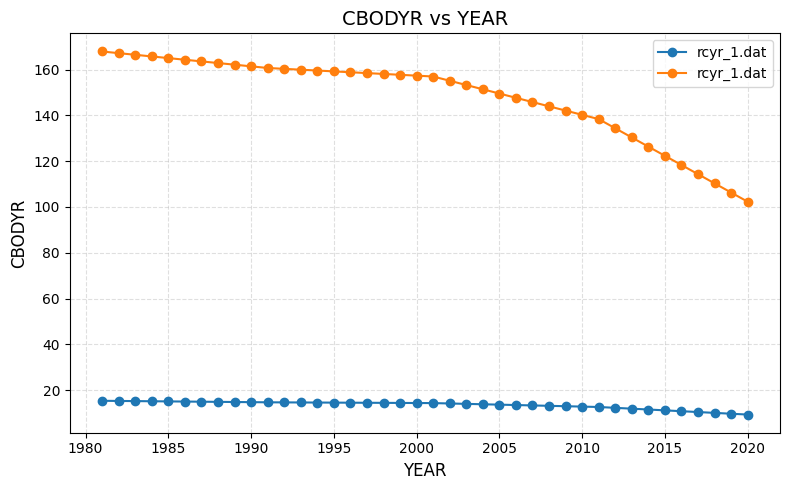

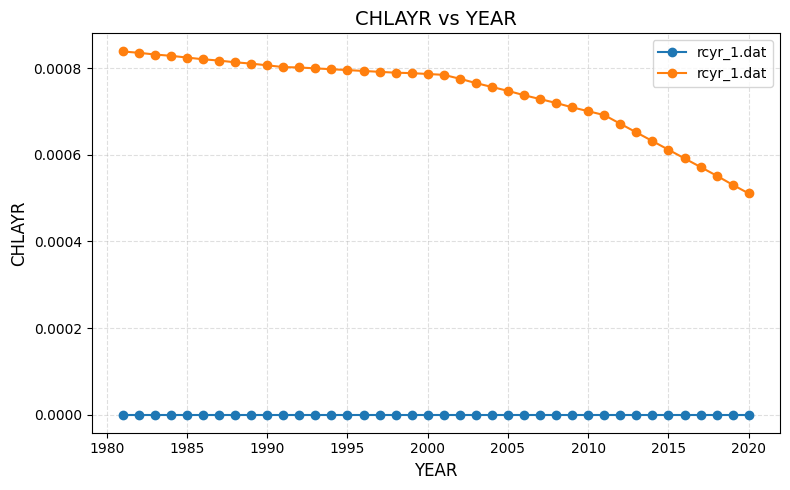

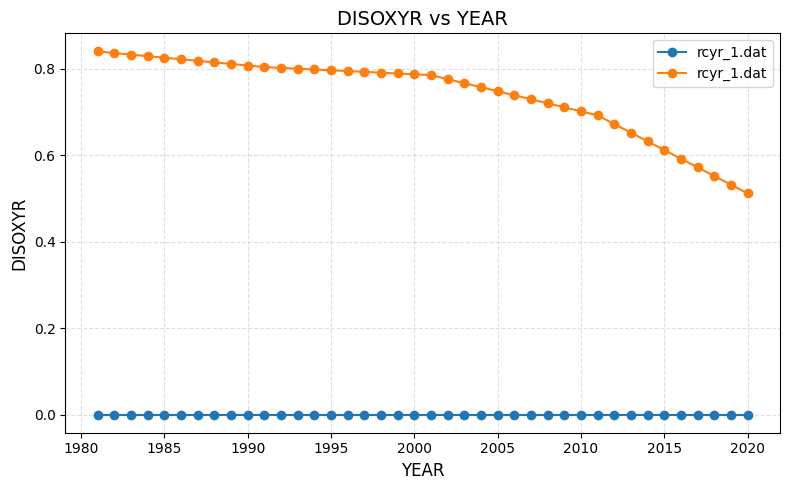

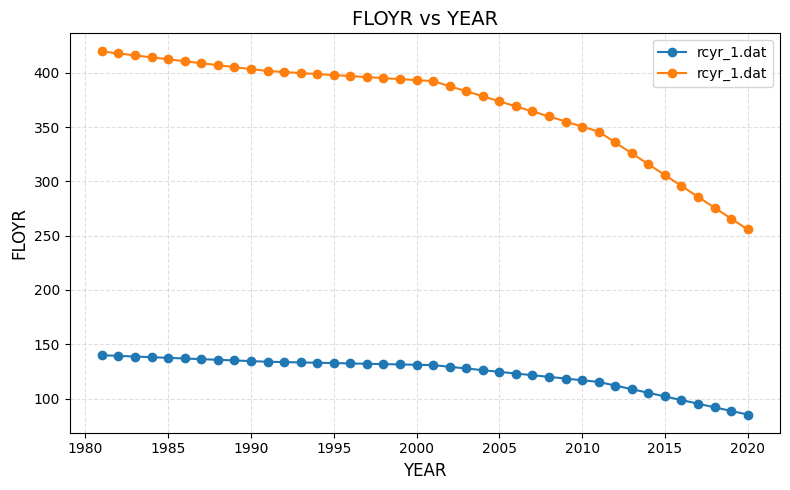

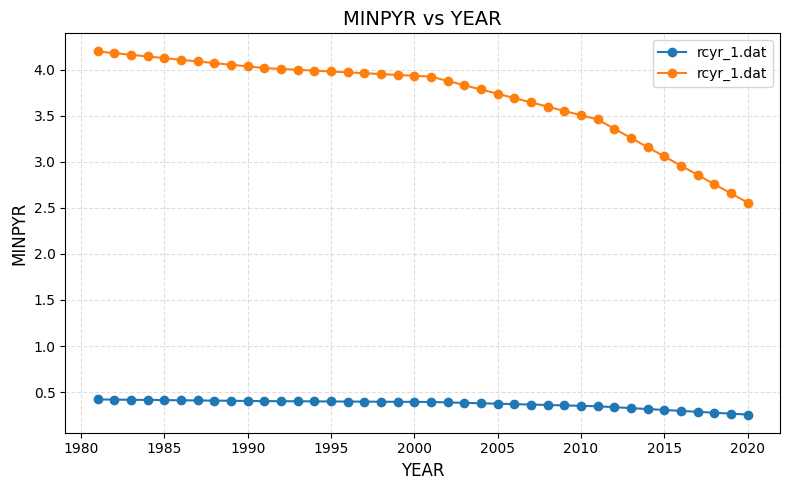

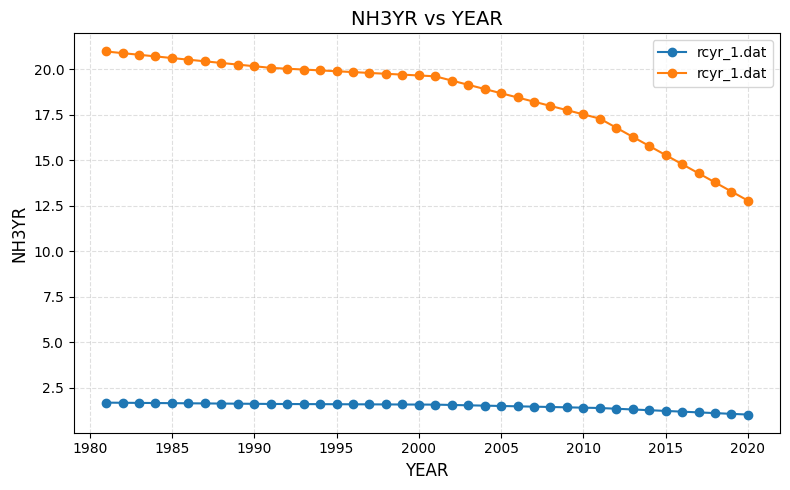

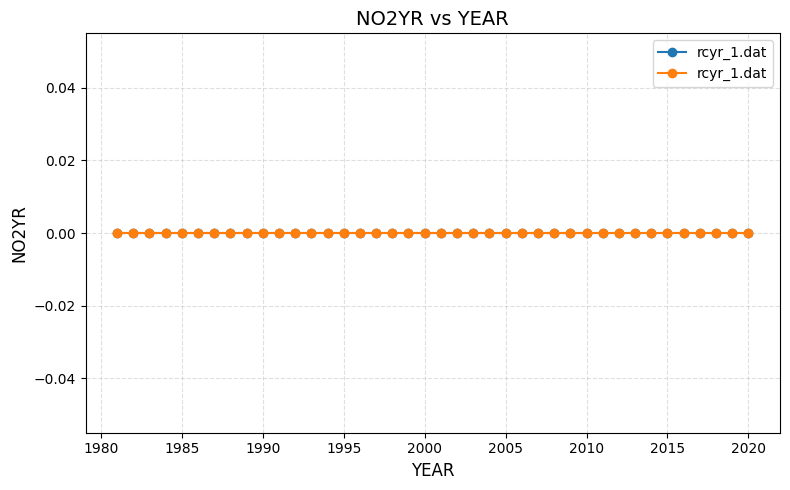

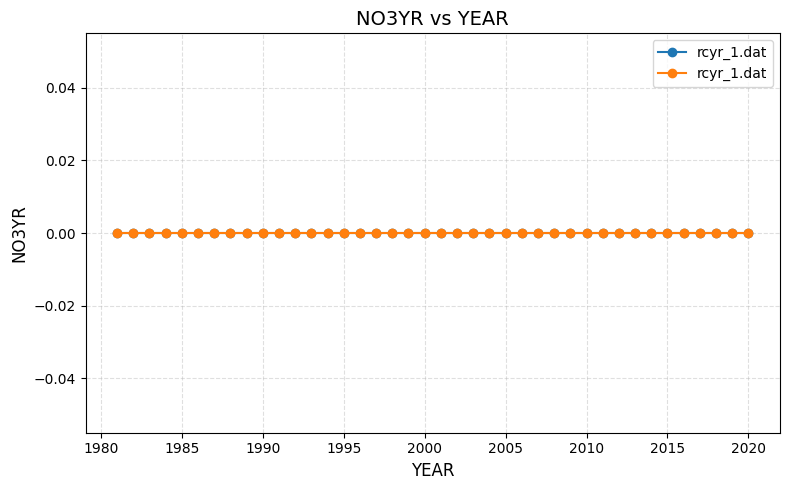

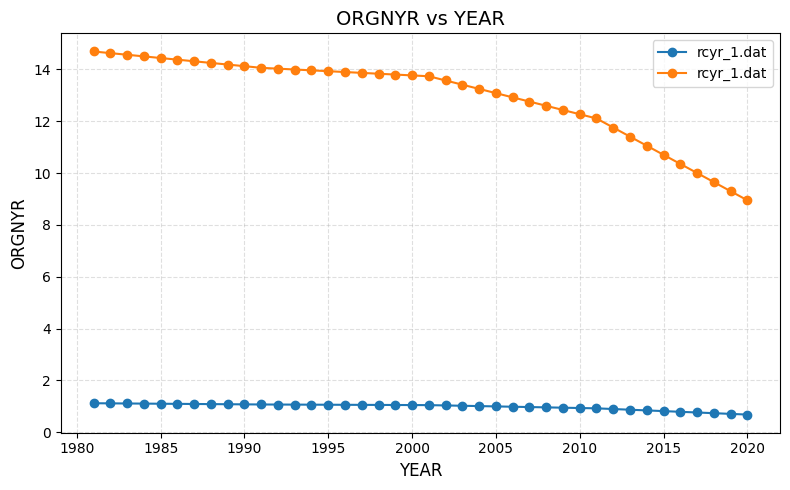

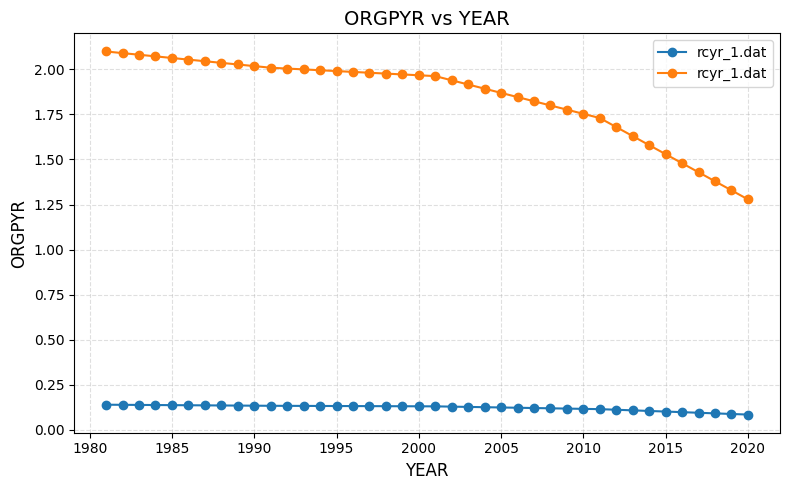

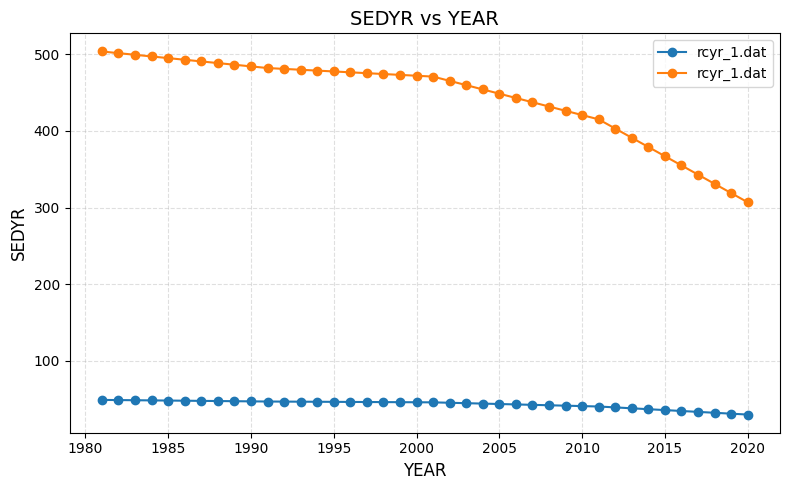

: 

In [ ]:
base = r"C:\SWAT\RSWAT\cubillas\mc_realizations"

files = [
    fr"{base}\run000157_real000529_1\rcyr_1.dat",
    fr"{base}\run000157_real000530_2\rcyr_1.dat",
    #fr"{base}\rcyr_3.dat",
]

compare_rcyr_files(files, skip_title_lines=5)

